In [ ]:
pip install scikit-learn pandas matplotlib

In [ ]:
#importando biblioteca
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


#carregar o dataset
iris = load_iris()

# Criar o DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df




,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
# # Adicionar uma nova coluna com a espécie de cada flor
df["especie"] = [
    iris.target_names[i] for i in iris.target
 ]


# Visualizar as primeiras linhas
print(df.head(10))



   sepal length (cm)  sepal width (cm)  ...  especie            formato
0                5.1               3.5  ...   setosa  sepal length (cm)
1                4.9               3.0  ...   setosa  sepal length (cm)
2                4.7               3.2  ...   setosa  sepal length (cm)
3                4.6               3.1  ...   setosa  sepal length (cm)
4                5.0               3.6  ...   setosa  sepal length (cm)
5                5.4               3.9  ...   setosa  sepal length (cm)
6                4.6               3.4  ...   setosa  sepal length (cm)
7                5.0               3.4  ...   setosa  sepal length (cm)
8                4.4               2.9  ...   setosa  sepal length (cm)
9                4.9               3.1  ...   setosa  sepal length (cm)

[10 rows x 6 columns]


In [ ]:


x = iris.data
y = iris.target

#separar o dataset em duas partes: treino e teste

x_train, x_test ,y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify = y)

# NORMALIZAR OS DADOS
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#criar o classificador KNN
knn = KNeighborsClassifier(n_neighbors = 5)

#TREINAR O MODELO
knn.fit(x_train,y_train)

# FAZER PREVISOES
y_pred = knn.predict(x_test)

# 8. Avaliar o modelo
accuracy = accuracy_score(y_test, y_pred)

print("Acurácia:", accuracy)
print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))



Acurácia: 0.9333333333333333

Relatório de classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## Adicionando nova flor para classificação

In [ ]:
# Medidas de uma nova flor
nova_flor = [[5.1, 3.5, 1.4, 0.2]]

# Aplicar a mesma padronização
nova_flor = scaler.transform(nova_flor)

# Prever a espécie
previsao = knn.predict(nova_flor)

nome_especie = iris.target_names[previsao[0]]

print("Espécie prevista:", nome_especie)

Espécie prevista: setosa


In [ ]:
# Medidas de uma nova flor
nova_flor = [[5.4, 3.5, 3.4, 1.2]]

# Aplicar a mesma padronização
nova_flor = scaler.transform(nova_flor)

# Prever a espécie
previsao = knn.predict(nova_flor)

nome_especie = iris.target_names[previsao[0]]

print("Espécie prevista:", nome_especie)

Espécie prevista: versicolor


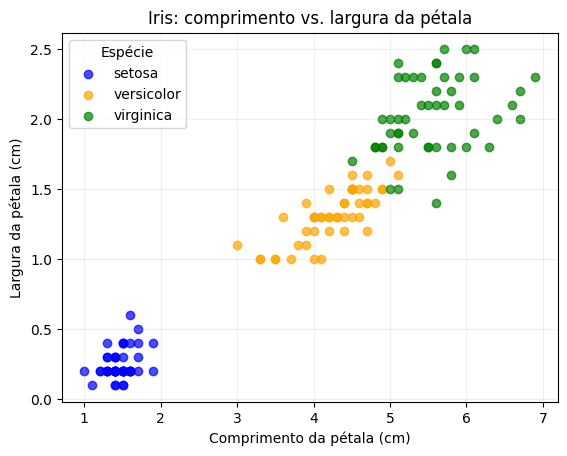

In [ ]:
import matplotlib.pyplot as plt

cores = {
    "setosa": "blue",
    "versicolor": "orange",
    "virginica": "green"
}

for especie, grupo in df.groupby("especie"):
    plt.scatter(
        grupo["petal length (cm)"],
        grupo["petal width (cm)"],
        label=especie,
        alpha=0.7,
        color=cores[especie]
    )

plt.title("Iris: comprimento vs. largura da pétala")
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")
plt.legend(title="Espécie")
plt.grid(alpha=0.2)
plt.show()